In [1]:
# ===== Colab/T4-friendly setup =====
import sys, subprocess, os, zipfile, re, random, shutil, math, textwrap, itertools, pathlib
from pathlib import Path

# Minimal installs (fast on Colab)
pkgs = [
    "torch>=2.2.0", "torchvision>=0.17.0", "torchaudio>=2.2.0",
    "scikit-learn>=1.3.0", "pandas>=2.1.0", "numpy>=1.25.0",
    "matplotlib>=3.7.0", "tqdm>=4.66.0", "Pillow>=10.0.0",
    "scikit-image>=0.22.0",  # for HOG
    "opencv-python>=4.8.0",  # SIFT needs contrib; we’ll try to enable if available
    "opencv-contrib-python>=4.8.0",  # may fail on some Colab images; code handles fallback
]
subprocess.call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torchvision
from torchvision import transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from tqdm import tqdm
from PIL import Image
from skimage.feature import hog

try:
    import cv2
    OPENCV_HAS_SIFT = hasattr(cv2, "SIFT_create") or hasattr(cv2, "xfeatures2d")  # contrib adds xfeatures2d
except Exception:
    OPENCV_HAS_SIFT = False

# Reproducibility
def set_seed(seed=42):
    """Set Python, NumPy, and Torch seeds for reproducibility across CPU and GPU."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# <<< EDIT THIS >>>
ZIP_ON_DRIVE = "/content/drive/MyDrive/question01.zip"  # <-- your real path

EXTRACT_DIR = Path("/content/signatures_data")
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_ON_DRIVE, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Mounted at /content/drive
Extracted to: /content/signatures_data


In [3]:
def build_image_table(root: Path):
    """
    Walk the extracted root and create a DataFrame with columns:
      - filepath: absolute path to image
      - signer: string label (class)

    Strategy:
    1) If immediate subfolders contain images, use folder names as class labels.
    2) Else, attempt to parse signer id from filename leading digits (e.g., '001_*' -> '001').
       Fallback to parent folder name if available.
    """
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    rows = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            rows.append(p)
    assert rows, f"No images found under {root}"

    # Heuristic: are there class folders (one level down)?
    immediate_subdirs = [d for d in root.iterdir() if d.is_dir()]
    folder_has_images = False
    for d in immediate_subdirs:
        if any((f.suffix.lower() in exts) for f in d.glob("*")):
            folder_has_images = True
            break

    data = []
    if folder_has_images:
        for f in rows:
            # class = first directory under root
            try:
                rel = f.relative_to(root)
                signer = rel.parts[0]
            except Exception:
                signer = f.parent.name
            data.append((str(f), signer))
    else:
        # Parse from filename: leading digits or alpha block before underscore/dash
        for f in rows:
            m = re.match(r"^([A-Za-z0-9]+)[_\-\s]", f.name)
            if m:
                signer = m.group(1)
            else:
                # fallback to parent folder
                signer = f.parent.name
            data.append((str(f), signer))
    df = pd.DataFrame(data, columns=["filepath", "signer"])
    # Drop classes with too few samples (e.g., < 3) to keep CV stable
    vc = df["signer"].value_counts()
    keep = vc[vc >= 3].index
    df = df[df["signer"].isin(keep)].reset_index(drop=True)
    return df

df = build_image_table(EXTRACT_DIR)
print(df.head(), "\nClasses:", df["signer"].nunique(), "Images:", len(df))

                                            filepath   signer
0  /content/signatures_data/sign_data/sign_data/t...  0110016
1  /content/signatures_data/sign_data/sign_data/t...  0110016
2  /content/signatures_data/sign_data/sign_data/t...  0202016
3  /content/signatures_data/sign_data/sign_data/t...  0107016
4  /content/signatures_data/sign_data/sign_data/t...  0107016 
Classes: 53 Images: 4298


In [4]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["signer"], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df["signer"], random_state=42)

classes = sorted(df["signer"].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

len(train_df), len(val_df), len(test_df), len(classes)

(3008, 645, 645, 53)

In [5]:
IMG_SIZE = 224
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply([transforms.ColorJitter(0.1,0.1,0.1,0.05)], p=0.3),
    transforms.RandomRotation(3),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

class SignaturesDS(Dataset):
    """
    PyTorch dataset for signature images.

    Args:
        frame: DataFrame with columns 'filepath' and 'signer'.
        tfms: torchvision transforms for preprocessing.
        class_to_idx: mapping from signer string to integer class id.
    Returns:
        (image_tensor, class_id) pairs.
    """
    def __init__(self, frame, tfms, class_to_idx):
        self.frame = frame.reset_index(drop=True)
        self.tfms = tfms
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row.filepath).convert("RGB")
        img = self.tfms(img)
        y = self.class_to_idx[row.signer]
        return img, y

BATCH = 32
train_ds = SignaturesDS(train_df, train_tfms, class_to_idx)
val_ds   = SignaturesDS(val_df,   eval_tfms,  class_to_idx)
test_ds  = SignaturesDS(test_df,  eval_tfms,  class_to_idx)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]
/tmp/ipython-input-190596235.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))
Epoch 1/15:   0%|          | 0/94 [00:00<?, ?it/s]/tmp/ipython-input-190596235.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=="cuda")):


Epoch 1: train_loss=2.2851 val_loss=1.7143 train_acc=0.296 val_acc=0.436


Epoch 2: train_loss=1.3421 val_loss=1.4318 train_acc=0.565 val_acc=0.569


Epoch 3: train_loss=0.7388 val_loss=2.8269 train_acc=0.776 val_acc=0.360


...

Epoch 11: train_loss=0.0633 val_loss=0.4246 train_acc=0.984 val_acc=0.885


Epoch 12: train_loss=0.0433 val_loss=0.3792 train_acc=0.989 val_acc=0.890


Epoch 13: train_loss=0.0388 val_loss=0.3825 train_acc=0.989 val_acc=0.888


Epoch 14: train_loss=0.0318 val_loss=0.3548 train_acc=0.993 val_acc=0.885


Epoch 15: train_loss=0.0342 val_loss=0.3562 train_acc=0.992 val_acc=0.885


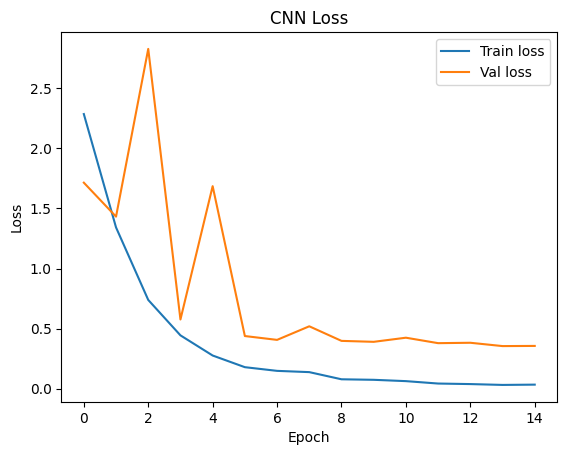

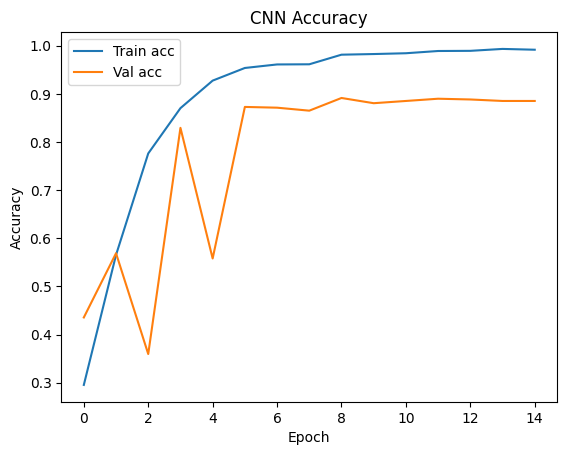

Test Acc: 0.8822
              precision    recall  f1-score   support

         001     1.0000    1.0000    1.0000         7
         002     1.0000    1.0000    1.0000         7
         003     1.0000    1.0000    1.0000         7
         004     1.0000    1.0000    1.0000         8
         006     1.0000    1.0000    1.0000         8
         009     1.0000    1.0000    1.0000         7
          01     0.8372    0.8090    0.8229        89
     0102014     1.0000    1.0000    1.0000         1
     0103004     1.0000    1.0000    1.0000         1
     0104014     1.0000    1.0000    1.0000         1
     0105004     1.0000    1.0000    1.0000         1
     0106015     1.0000    1.0000    1.0000         2
     0107016     1.0000    1.0000    1.0000         1
     0108002     1.0000    1.0000    1.0000         1
     0110002     1.0000    1.0000    1.0000         1
     0110016     1.0000    1.0000    1.0000         1
     0111006     1.0000    1.0000    1.0000         1
     01130

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


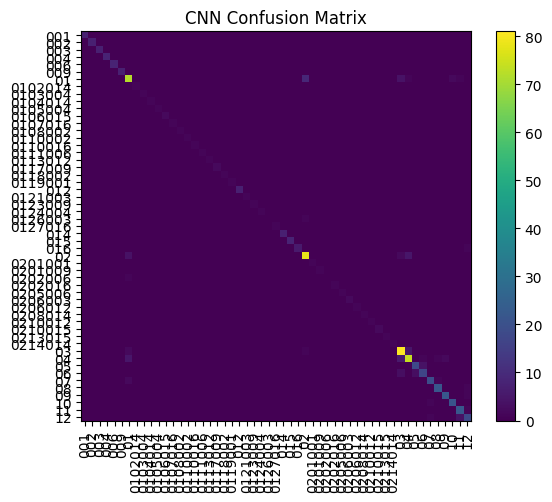

In [6]:
def make_resnet18(num_classes: int):
    """
    Create a ResNet-18 model adapted for signer classification.
    Uses torchvision pretrained weights if available, replaces the final fc layer.
    """
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

@torch.no_grad()
def evaluate(model, loader, device):
    """
    Evaluate model on a dataloader.

    Returns:
        dict with 'loss', 'acc', 'y_true', 'y_pred' for further metrics.
    """
    model.eval()
    ce = nn.CrossEntropyLoss()
    tot_loss, correct, n = 0.0, 0, 0
    y_true, y_pred = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = ce(logits, y)
        tot_loss += loss.item() * y.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        n += y.size(0)
        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(preds.detach().cpu().tolist())
    return {"loss": tot_loss / n, "acc": correct / n, "y_true": y_true, "y_pred": y_pred}

def train_cnn(model, train_dl, val_dl, device, epochs=15, lr=3e-4, wd=1e-4):
    """
    Train a CNN with AdamW + cosine schedule and mixed precision on T4.

    Returns:
        model (best on val), history dict with lists for 'train_loss', 'val_loss', 'train_acc', 'val_acc'.
    """
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))
    ce = nn.CrossEntropyLoss()

    best_val = float("inf"); best_state = None
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(1, epochs+1):
        model.train()
        running_loss, correct, n = 0.0, 0, 0
        for x, y in tqdm(train_dl, desc=f"Epoch {ep}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device=="cuda")):
                logits = model(x)
                loss = ce(logits, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            running_loss += loss.item() * y.size(0)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            n += y.size(0)

        train_loss = running_loss / n
        train_acc = correct / n

        val_stats = evaluate(model, val_dl, device)
        val_loss, val_acc = val_stats["loss"], val_stats["acc"]
        hist["train_loss"].append(train_loss); hist["val_loss"].append(val_loss)
        hist["train_acc"].append(train_acc);   hist["val_acc"].append(val_acc)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        sched.step()
        print(f"Epoch {ep}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state, strict=True)
    return model, hist

model = make_resnet18(num_classes=len(classes))
model, history = train_cnn(model, train_dl, val_dl, DEVICE, epochs=15, lr=3e-4)

# Learning curves
plt.figure()
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("CNN Loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(history["train_acc"], label="Train acc")
plt.plot(history["val_acc"], label="Val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("CNN Accuracy"); plt.legend(); plt.show()

# Test metrics
test_stats = evaluate(model, test_dl, DEVICE)
print(f"Test Acc: {test_stats['acc']:.4f}")
print(classification_report(test_stats["y_true"], test_stats["y_pred"], target_names=classes, digits=4))

# Confusion matrix
cm = confusion_matrix(test_stats["y_true"], test_stats["y_pred"])
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("CNN Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.tight_layout(); plt.show()

Extracting features: 100%|██████████| 645/645 [00:08<00:00, 76.22it/s] 
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


HOG+LinearSVC Acc: 0.9627906976744186
              precision    recall  f1-score   support

         001     1.0000    1.0000    1.0000         7
         002     1.0000    1.0000    1.0000         7
         003     1.0000    1.0000    1.0000         7
         004     1.0000    1.0000    1.0000         8
         006     1.0000    1.0000    1.0000         8
         009     1.0000    1.0000    1.0000         7
          01     0.9540    0.9326    0.9432        89
     0102014     1.0000    1.0000    1.0000         1
     0103004     1.0000    1.0000    1.0000         1
     0104014     1.0000    1.0000    1.0000         1
     0105004     1.0000    1.0000    1.0000         1
     0106015     1.0000    1.0000    1.0000         2
     0107016     1.0000    1.0000    1.0000         1
     0108002     1.0000    1.0000    1.0000         1
     0110002     1.0000    1.0000    1.0000         1
     0110016     1.0000    1.0000    1.0000         1
     0111006     1.0000    1.0000    1.0000

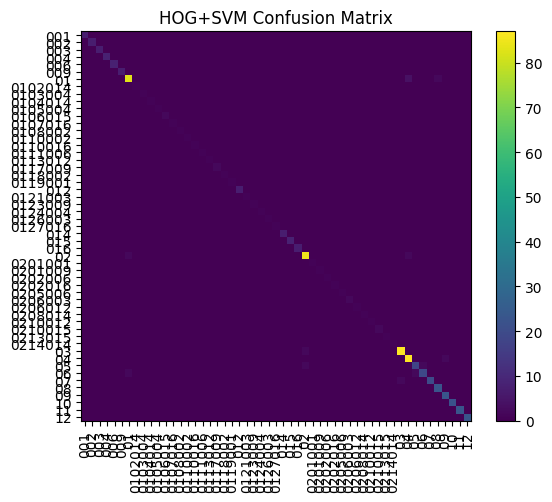

In [7]:
def extract_hog_feature(path, size=(128,128)):
    """
    Load image from path, resize, and compute HOG descriptor.
    Returns a 1D numpy array.
    """
    img = Image.open(path).convert("L").resize(size, Image.BILINEAR)
    arr = np.array(img)
    feat = hog(arr, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), block_norm='L2-Hys', transform_sqrt=True, feature_vector=True)
    return feat

def build_features(frame, extractor):
    """
    Convert a DataFrame of filepaths + signer to (X, y, label_names) for sklearn models.
    extractor: callable(path) -> 1D feature vector.
    """
    X, y = [], []
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc="Extracting features"):
        X.append(extractor(row.filepath))
        y.append(class_to_idx[row.signer])
    return np.stack(X), np.array(y)

Xtr_hog, ytr = build_features(train_df, extract_hog_feature)
Xva_hog, yva = build_features(val_df,   extract_hog_feature)
Xte_hog, yte = build_features(test_df,  extract_hog_feature)

hog_clf = make_pipeline(StandardScaler(with_mean=False), LinearSVC(C=1.0, max_iter=5000))
hog_clf.fit(np.vstack([Xtr_hog, Xva_hog]), np.hstack([ytr, yva]))
pred = hog_clf.predict(Xte_hog)
print("HOG+LinearSVC Acc:", accuracy_score(yte, pred))
print(classification_report(yte, pred, target_names=classes, digits=4))

cm = confusion_matrix(yte, pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("HOG+SVM Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.tight_layout(); plt.show()

BoW encode: 100%|██████████| 645/645 [00:00<00:00, 1528.23it/s]


SIFT+BoW+SVM Acc: 0.07596899224806201
              precision    recall  f1-score   support

         001     0.0000    0.0000    0.0000         7
         002     0.0000    0.0000    0.0000         7
         003     0.0000    0.0000    0.0000         7
         004     0.0074    0.1250    0.0139         8
         006     0.0000    0.0000    0.0000         8
         009     0.0000    0.0000    0.0000         7
          01     0.1239    0.1573    0.1386        89
     0102014     0.0000    0.0000    0.0000         1
     0103004     0.0000    0.0000    0.0000         1
     0104014     0.0000    0.0000    0.0000         1
     0105004     0.0000    0.0000    0.0000         1
     0106015     0.0000    0.0000    0.0000         2
     0107016     0.0000    0.0000    0.0000         1
     0108002     0.0000    0.0000    0.0000         1
     0110002     0.0000    0.0000    0.0000         1
     0110016     0.0000    0.0000    0.0000         1
     0111006     0.0000    0.0000    0.0000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


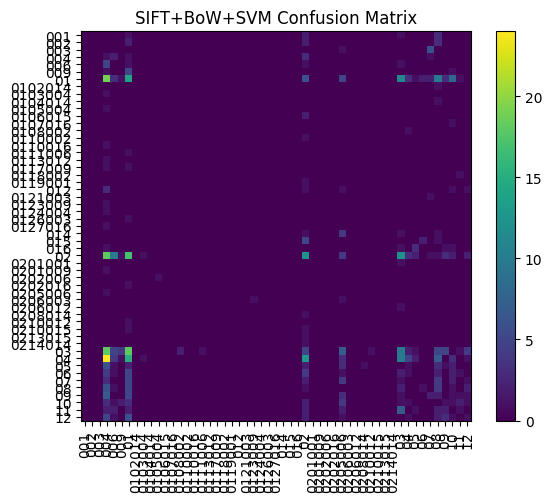

In [8]:
def sift_bow_features(frame, k=200):
    """
    Build Bag-of-Visual-Words features using SIFT keypoints.
    Steps:
      1) Detect SIFT/ORB keypoints + descriptors per image.
      2) KMeans on a sample of descriptors to form visual vocabulary (size k).
      3) Histogram encode each image's descriptors over the vocabulary.
    Returns:
      X, y, kmeans_model (for reuse), sift
    """
    if not OPENCV_HAS_SIFT:
        raise RuntimeError("OpenCV-contrib SIFT not available; skipping SIFT baseline.")

    # SIFT detector
    sift = None
    if hasattr(cv2, "SIFT_create"):
        sift = cv2.SIFT_create()
    elif hasattr(cv2, "xfeatures2d"):
        sift = cv2.xfeatures2d.SIFT_create()
    assert sift is not None

    # Collect descriptors (sample to cap memory/time)
    desc_list, y = [], []
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc="SIFT descriptors"):
        img = cv2.imread(row.filepath, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (256,256))
        kps, des = sift.detectAndCompute(img, None)
        if des is not None:
            # limit per image (speed)
            if len(des) > 300: des = des[:300]
            desc_list.append(des)
            y.append(class_to_idx[row.signer])
    all_desc = np.vstack([d for d in desc_list if d is not None])
    # KMeans vocab
    from sklearn.cluster import MiniBatchKMeans
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=42)
    kmeans.fit(all_desc)

    # Encode BoW hist per image
    X = []
    yi = []
    it = tqdm(zip(desc_list, y), total=len(y), desc="BoW encode")
    for des, lab in it:
        if des is None:
            X.append(np.zeros(k)); yi.append(lab); continue
        words = kmeans.predict(des)
        hist, _ = np.histogram(words, bins=np.arange(k+1))
        X.append(hist.astype(np.float32))
        yi.append(lab)
    return np.vstack(X), np.array(yi), kmeans, sift

if OPENCV_HAS_SIFT:
    Xtr_sift, ytr_sift, vocab, sift = sift_bow_features(train_df, k=200)
    Xva_sift, yva_sift, _, _       = sift_bow_features(val_df,   k=200)
    Xte_sift, yte_sift, _, _       = sift_bow_features(test_df,  k=200)

    sift_clf = make_pipeline(StandardScaler(with_mean=False), SVC(C=5.0, kernel="linear", probability=False))
    sift_clf.fit(np.vstack([Xtr_sift, Xva_sift]), np.hstack([ytr_sift, yva_sift]))
    pred = sift_clf.predict(Xte_sift)
    print("SIFT+BoW+SVM Acc:", accuracy_score(yte_sift, pred))
    print(classification_report(yte_sift, pred, target_names=classes, digits=4))

    cm = confusion_matrix(yte_sift, pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title("SIFT+BoW+SVM Confusion Matrix")
    plt.colorbar()
    plt.xticks(range(len(classes)), classes, rotation=90)
    plt.yticks(range(len(classes)), classes)
    plt.tight_layout(); plt.show()
else:
    print("OpenCV SIFT not available; skipping SIFT baseline.")